In [5]:
%matplotlib ipympl

import matplotlib.pyplot as plot
import numpy as np

In [6]:
#
# Can we define `m` with an accessor?
# * Verify indexes
# * How to animate
#

grid_columns = 8
grid_rows    = 8

# global m
# global _m



# def _create_m ():
#     global m
#     m = [ [ ( 0, 0, 0 ) for _ in range( grid_columns ) ] for _ in range( grid_rows ) ]




# def add_frame ():
#     global _m, m
#     _m.append( m )
#     m = _create_m()



# _create_m()
# _m = []

In [7]:
import matplotlib.animation as anim
import matplotlib.pyplot as plot
import numpy as np



class M:
    def __init__ ( self ):
        self.frames = [ MFrame() ]



    def __getitem__ ( self, pos ):
        return self.frames[-1][pos]
    


    def addFrame ( self ):
        self.frames.append( MFrame() )



    def draw ( self ):
        figure, axes = plot.subplots()
        figure.set_frameon( False )
        
        ( width, height ) = self.shape()
        
        axes.grid( which = 'major', axis = 'both', color = 'w', linewidth = '5' )
        axes.set_xticks( np.arange( -0.5, width, 1 ) )
        axes.set_yticks( np.arange( -0.5, height, 1 ) )
        axes.set_xticklabels( [] )
        axes.set_yticklabels( [] )

        image = axes.imshow( self.frames[0].getCells() )

        if len( self.frames ) == 1:
            plot.show()
            return image

        frame_update = lambda frame: self.drawFrame( frame, image )
        animation = anim.FuncAnimation( fig = figure, func = frame_update, frames = len( self.frames ), interval = 40 )
        plot.show()

        return animation



    def drawFrame ( self, frame, image ):
        image.set_data( self.frames[frame].getCells() )



    def shape ( self ):
        return self.frames[-1].shape()



class MFrame:
    FRAME_ROW_COUNT = 8

    def __init__ ( self ):
        self.rows = [ MFrameRow() for _ in range( MFrame.FRAME_ROW_COUNT ) ]



    def __getitem__ ( self, pos ):
        if pos < 0 or len( self.rows ) <= pos:
            raise Exception( f'Invalid row index {pos}; must be between 0 and {len( self.rows )}' )
        
        return self.rows[pos]



    def getCells ( self ):
        return [ row.cells for row in self.rows ]



    def shape ( self ):
        return ( len( self.rows ), self.rows[0].getCellCount() )



class MFrameRow:
    ROW_CELL_COUNT = 8

    def __init__ ( self ):
        self.cells = [ ( 0, 0, 0 ) for _ in range( MFrameRow.ROW_CELL_COUNT ) ]



    def __getitem__ ( self, pos ):
        if pos < 0 or len( self.cells ) <= pos:
            raise Exception( f'Invalid column index {pos}; must be between 0 and {len( self.cells )}' )
        
        return self.cells[pos]
    


    def __setitem__ ( self, pos, value ):
        if pos < 0 or len( self.cells ) <= pos:
            raise Exception( f'Invalid column index {pos}; must be between 0 and {len( self.cells )}' )
        
        self.cells[pos] = value



    def getCellCount ( self ):
        return len( self.cells )



def add_frame ():
    global m
    m.addFrame()



m = M()

In [8]:
#
# Example 1.
#

m = M()



colors = [
    ( 255,   0,   0 ),
    ( 255, 127,   0 ),
    ( 255, 255,   0 ),
    (   0, 218,   0 ),
    (   0,   0, 218 ),
    ( 218,   0, 218 )
]

num_colors = len( colors )
for i in range( num_colors ):
    if i != 0:
        add_frame()

    for j in range( num_colors ):
        delta = j - i
        if -1 <= delta and delta <= 1:
            m[j+1][j+1] = colors[j]

        delta = delta + num_colors
        if -1 <= delta and delta <= 1:
            m[j+1][j+1] = colors[j]

        delta = delta - 2 * num_colors
        if -1 <= delta and delta <= 1:
            m[j+1][j+1] = colors[j]

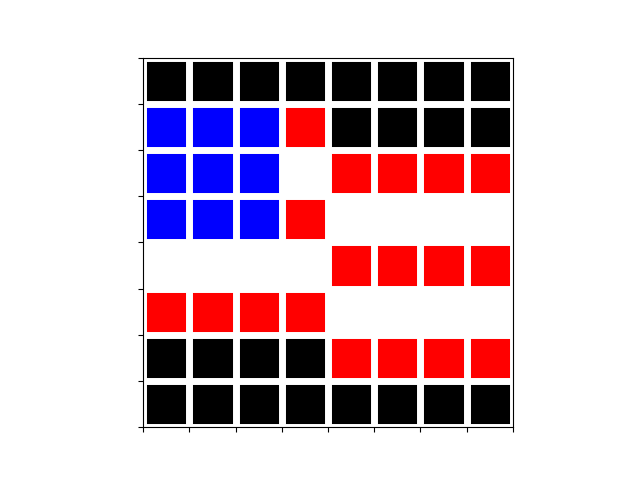

In [9]:
#
# Example 2.
#

m = M()

color_map = {
    'b': (   0,   0, 255 ),
    'k': (   0,   0,   0 ),
    'r': ( 255,   0,   0 ),
    'w': ( 255, 255, 255 )
}


def apply_row_rotation ( grid, rotation ):
    return [ [ grid[( row + rotation[col] ) % 8][col] for col in range( 8 )] for row in range( 8 ) ]

def grid_to_image ( grid ):
    global m

    for row in range( 8 ):
        for col in range( 8 ):
            m[row][col] = color_map[grid[row][col]]

def rotation_vector ( offset ):
    return [ -1 if ( -offset + col ) % 8 >= 4 else 0 for col in range( 8 ) ]
    # return [ sign( ( offset + col ) % 8 - 4 ) + ( ( offset + col ) % 4 ) // 2 for col in range( 8 ) ]

def sign ( i ):
    return -1 if i < 0 else 1 if i > 0 else 0

def string_to_grid ( s, auto_pad = False ):
    return [ [ s[row * 8 + col] for col in range( 8 ) ] for row in range( 8 ) ]

def parse_grid ( grid, auto_pad = False ):
    global m
    grid = ''.join( grid )

    if len( grid ) != 64:
        raise Exception( 'Grid size must be 8x8.' ) # cheating!
    
    if auto_pad:
        raise Exception( 'Auto padding is not enabled.' )
    
    for row in range( 8 ):
        for col in range( 8 ):
            m[row][col] = color_map[grid[row * 8 + col]]


    
grid_base = [
    'kkkkkkkk',
    'bbbrrrrr',
    'bbbwwwww',
    'bbbrrrrr',
    'wwwwwwww',
    'rrrrrrrr',
    'kkkkkkkk',
    'kkkkkkkk'
]

grid_base = string_to_grid( ''.join( grid_base ) )

rotation_vectors = [
    [ 0, 0, 1, 1, 0, 0, -1, -1 ],
    [ 0, 1, 1, 0, 0, -1, -1, 0 ],
    [ 1, 1, 0, 0, -1, -1, 0, 0 ],
    [ 1, 0, 0, -1, -1, 0, 0, 1 ],
    [ 0, 0, -1, -1, 0, 0, 1, 1 ],
    [ 0, -1, -1, 0, 0, 1, 1, 0 ],
    [ -1, -1, 0, 0, 1, 1, 0, 0 ],
    [ -1, 0, 0, 1, 1, 0, 0, -1 ]
]
rotation_vectors = [ [ rotation_vectors[row][col] - 1 for col in range( 8 ) ] for row in range( 8 ) ]

# rotation_vectors = [
#     [ -1, -1, -1, 0, 0, 0, -1, -1 ],
#     [ -1, -1, 0, 0, 0, -1, -1, -1 ],
#     [ -1, 0, 0, 0, -1, -1, -1, -1 ],
#     [ 0, 0, 0, -1, -1, -1, -1, -1 ],
#     [ 0, 0, -1, -1, -1, -1, -1, 0 ],
#     [ 0, -1, -1, -1, -1, -1, 0, 0 ],
#     [ -1, -1, -1, -1, -1, 0, 0, 0 ],
#     [ -1, -1, -1, -1, 0, 0, 0, -1 ]
# ]

for ix in range( 8 ):
    if ix != 0:
        add_frame()
        
    # grid_to_image( grid_base )#apply_row_rotation( grid_base, rotation_vectors[ix] ) )#( ix ) ) )
    grid_to_image( apply_row_rotation( grid_base, rotation_vector( ix ) ) )

_ = m.draw()